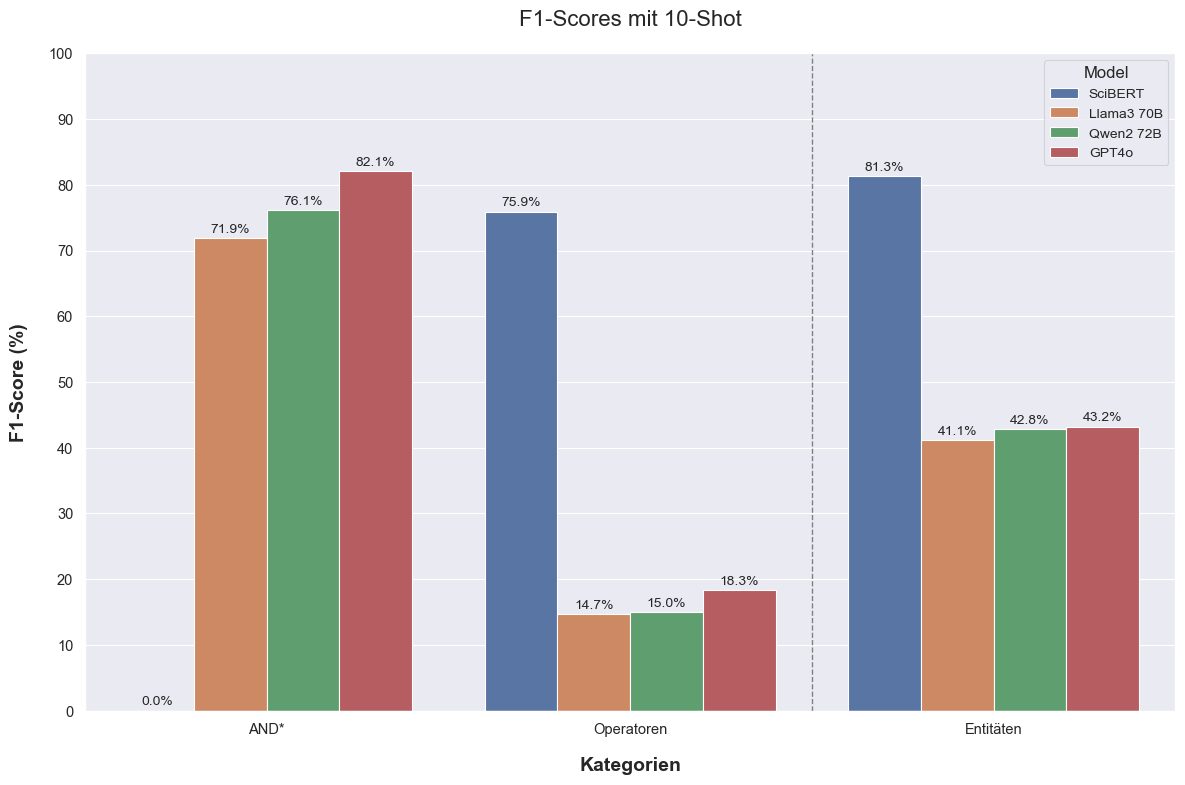

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_f1_scores_comparison_seaborn(operator_metrics, entity_metrics):
    # Prepare the data
    data = []
    for model in operator_metrics.keys():
        data.append({'Model': model, 'Category': 'AND*', 'F1-Score': operator_metrics[model]['AND*']})
        data.append({'Model': model, 'Category': 'Operatoren', 'F1-Score': operator_metrics[model]['Durchschnitt']})
        data.append({'Model': model, 'Category': 'Entitäten', 'F1-Score': entity_metrics[model]})

    df = pd.DataFrame(data)

    # Set up the plot
    sns.set_theme(style="darkgrid")
    sns.set_context("paper", font_scale=1.2)
    plt.figure(figsize=(12, 8))

    # Create the grouped bar plot
    ax = sns.barplot(x='Category', y='F1-Score', hue='Model', data=df, palette='deep')

    # Customize the plot
    plt.title('F1-Scores mit 10-Shot', fontsize=16, pad=20)
    plt.xlabel('Kategorien', fontsize=14, fontweight='bold', labelpad=15)
    plt.ylabel('F1-Score (%)', fontsize=14, fontweight='bold', labelpad=15)
    plt.ylim(0, 100)
    plt.yticks(np.arange(0, 101, 10))

    # Add percentage labels on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=10, padding=2)

    # Adjust legend
    plt.legend(title='Model', title_fontsize='12', fontsize='10', loc='best')

    # Add separator line before "Entitäten"
    plt.axvline(x=1.5, color='gray', linestyle='--', linewidth=1)

    # Adjust layout and save
    plt.tight_layout()
    plt.savefig('pics/10_shot.png', bbox_inches='tight')
    plt.show()

# Data from the tables
operator_metrics = {
    'SciBERT': {'AND*': 0.0, 'Durchschnitt': 75.9},
    'Llama3 70B': {'AND*': 71.9, 'Durchschnitt': 14.7},
    'Qwen2 72B': {'AND*': 76.1, 'Durchschnitt': 15.0},
    'GPT4o': {'AND*': 82.1, 'Durchschnitt': 18.3}
}

entity_metrics = {
    'SciBERT': 81.3,
    'Llama3 70B': 41.1,
    'Qwen2 72B': 42.8,
    'GPT4o': 43.2
}

plot_f1_scores_comparison_seaborn(operator_metrics, entity_metrics)

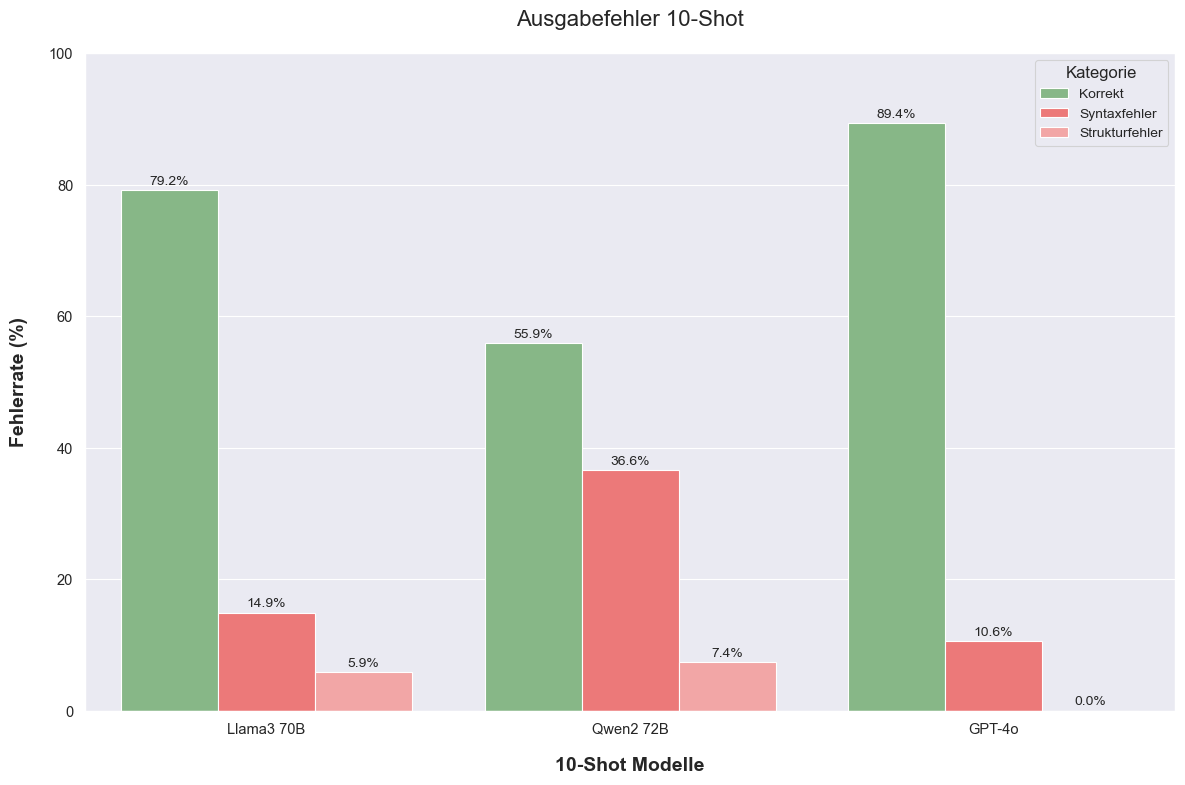

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_ausgabefehler_seaborn(error_data):
    df = pd.DataFrame(error_data)
    df_melted = pd.melt(df, id_vars=['Kategorie'], var_name='Model', value_name='Percentage')

    # Set the style to the default Seaborn style
    sns.set_theme(style="darkgrid")
    sns.set_context("paper", font_scale=1.2)

    plt.figure(figsize=(12, 8))
    colors = ['#7FBF7F', '#FF6666', '#FF9999']  # Green for correct, dark red for syntax error, light red for structure error
    ax = sns.barplot(x='Model', y='Percentage', hue='Kategorie', data=df_melted, palette=colors)

    plt.title('Ausgabefehler 10-Shot', fontsize=16, pad=20)
    plt.xlabel('10-Shot Modelle', fontsize=14, fontweight='bold', labelpad=15)
    plt.ylabel('Fehlerrate (%)', fontsize=14, fontweight='bold', labelpad=15)
    plt.ylim(0, 100)

    # Add percentage labels on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=10, padding=2)

    # Adjust legend
    plt.legend(title='Kategorie', title_fontsize='12', fontsize='10', loc='best')

    # Adjust layout and save
    plt.tight_layout()
    plt.savefig('pics/10_shot_ausgabefehler.png', bbox_inches='tight', dpi=300, facecolor='auto', edgecolor='auto')
    plt.show()

# Data from the table
error_data = {
    'Kategorie': ['Korrekt', 'Syntaxfehler', 'Strukturfehler'],
    'Llama3 70B': [79.2, 14.9, 5.9],
    'Qwen2 72B': [55.9, 36.6, 7.4],
    'GPT-4o': [89.4, 10.6, 0.0]
}

plot_ausgabefehler_seaborn(error_data)